# 04 — World Cup 2026 simulation

Fit the model, Monte-Carlo the real 2026 draw, and report each team's odds of advancing and winning the cup.

In [1]:
import sys; sys.path.append("..")
import pandas as pd
from src.dixon_coles import DixonColesModel
from src.simulate import monte_carlo
from wc2026_groups import GROUPS

df = pd.read_parquet("../data/processed/matches.parquet")
model = DixonColesModel().fit(df[df["date"] >= "2010-01-01"], xi=0.0019)
probs = monte_carlo(GROUPS, model, n_sims=10000, seed=2026)
probs.head(12)

,team,p_r32,p_r16,p_qf,p_sf,p_final,p_champion
0,Brazil,0.9925,0.9415,0.7692,0.5967,0.4272,0.2827
1,Argentina,0.9893,0.9111,0.7162,0.5196,0.3570,0.2089
2,Colombia,0.9596,0.8294,0.5877,0.3892,0.2038,0.1055
3,Spain,0.9598,0.8218,0.5552,0.3478,0.1653,0.0843
4,Uruguay,0.9411,0.7531,0.4790,0.2541,0.1114,0.0502
5,Ecuador,0.9435,0.7279,0.4268,0.2062,0.0868,0.0346
6,France,0.9244,0.6988,0.4162,0.1774,0.0846,0.0342
7,Portugal,0.8902,0.6435,0.3688,0.1233,0.0601,0.0251
8,England,0.9001,0.6453,0.3601,0.1276,0.0606,0.0226
9,Mexico,0.9119,0.6071,0.3293,0.1341,0.0588,0.0219


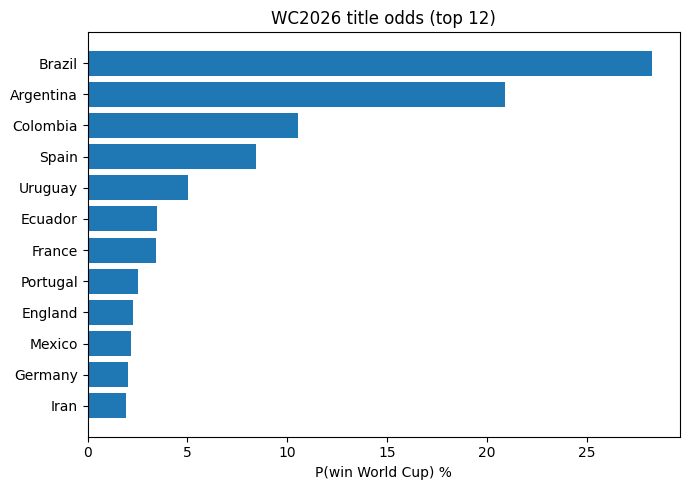

In [2]:
import matplotlib.pyplot as plt
top = probs.head(12).iloc[::-1]
plt.figure(figsize=(7, 5))
plt.barh(top["team"], top["p_champion"] * 100)
plt.xlabel("P(win World Cup) %"); plt.title("WC2026 title odds (top 12)")
plt.tight_layout(); plt.show()

In [3]:
stages = ["r32", "r16", "qf", "sf", "final", "champion"]
labels = {"r32": "qualify", "r16": "reach R16", "qf": "reach QF",
          "sf": "reach SF", "final": "reach final", "champion": "win cup"}
for team in probs["team"].head(3):
    row = probs[probs["team"] == team].iloc[0]
    print(team, "->", {labels[s]: f"{row[f'p_{s}'] * 100:.1f}%" for s in stages})

Brazil -> {'qualify': '99.2%', 'reach R16': '94.2%', 'reach QF': '76.9%', 'reach SF': '59.7%', 'reach final': '42.7%', 'win cup': '28.3%'}
Argentina -> {'qualify': '98.9%', 'reach R16': '91.1%', 'reach QF': '71.6%', 'reach SF': '52.0%', 'reach final': '35.7%', 'win cup': '20.9%'}
Colombia -> {'qualify': '96.0%', 'reach R16': '82.9%', 'reach QF': '58.8%', 'reach SF': '38.9%', 'reach final': '20.4%', 'win cup': '10.5%'}


In [4]:
# Each group's qualification favourite (p_r32 = reaching the knockout round of 32)
for g, teams in GROUPS.items():
    sub = probs[probs["team"].isin(teams)].sort_values("p_r32", ascending=False)
    fav = sub.iloc[0]
    print(f"Group {g}: favourite {fav['team']} (qualify {fav['p_r32'] * 100:.0f}%)")

Group A: favourite Mexico (qualify 91%)
Group B: favourite Switzerland (qualify 83%)
Group C: favourite Brazil (qualify 99%)
Group D: favourite Paraguay (qualify 78%)
Group E: favourite Ecuador (qualify 94%)
Group F: favourite Netherlands (qualify 86%)
Group G: favourite Iran (qualify 83%)
Group H: favourite Spain (qualify 96%)
Group I: favourite France (qualify 92%)
Group J: favourite Argentina (qualify 99%)
Group K: favourite Colombia (qualify 96%)
Group L: favourite England (qualify 90%)
